# 09 — Analyse de cohérence de la variable cible `is_underserved`

**Projet** : ObRail MSPR 2025-2026

**Source** : `data/processed/routes_processed.csv`

**Objectif** : le professeur a demandé une vérification que `is_underserved` couvre une zone géographique cohérente — c'est-à-dire que la sous-desserte reflète une structure réelle du réseau, et non du bruit réparti aléatoirement.

**Limite du dataset** : nous ne disposons que du pays de départ/arrivée (`departure_country`, `arrival_country`), pas de coordonnées GPS de gares individuelles. Une cartographie de gares au sens strict n'est donc pas réalisable avec les données actuelles.

**Démarche retenue** : plutôt qu'une carte de gares, on teste la cohérence de `is_underserved` à travers plusieurs angles structurels disponibles dans les données :
1. Cohérence géographique par pays (déjà vue en `07_cartographie.ipynb`, reprise ici pour analyse statistique)
2. Cohérence selon le caractère international du trajet
3. Cohérence selon la distance du trajet
4. Cohérence selon la part modale ferroviaire du pays (`rail_modal_share`)
5. Cohérence selon le type de service (jour / nuit)

>  **Note de lecture — ce que ces tests peuvent et ne peuvent pas montrer.**
> La cible est définie par des seuils sur `distance_km` et `days_active`. Plusieurs des tests ci-dessous portent donc, directement ou indirectement, sur des variables qui **servent à construire la cible** :
> - le test de **distance** (section 4) est **mécaniquement garanti** par la définition de la cible — c'est un contrôle de *cohérence interne*, pas une preuve indépendante ;
> - les tests **international** (section 3) et **type de service** (section 5) sont **partiellement circulaires** (les trajets internationaux sont plus longs ; les trains de nuit roulent moins de jours/an), donc leurs effets sont amplifiés par la construction de la cible.
> Les signaux les plus proches d'une structure *indépendante* sont le **pays** (section 1) et la **part modale** (section 4). L'objectif réaliste de ce notebook est donc de montrer que `is_underserved` est **structurée par la géographie et l'exploitation, et non aléatoire** — et non de la « valider » contre une vérité terrain externe.

> **Périmètre** : ces tests portent sur l'intégralité de `routes_processed.csv`, qui inclut des pays **exclus de la modélisation** (CH, TR, UA, AL, MK, MD, ME, RS, BG…). À garder en tête pour l'interprétation.

## 0. Imports et configuration

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

SEED = 42
np.random.seed(SEED)


def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for folder in [cwd] + list(cwd.parents):
        if (folder / 'data').exists() and (folder / 'src').exists() and (folder / 'models').exists():
            return folder
    raise FileNotFoundError('Could not find project root from current working directory')

ROOT = find_project_root()
PROCESSED_DIR = ROOT / 'data' / 'processed'
PLOT_DIR = ROOT / 'evaluation' / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('Imports OK')

Imports OK


## 1. Chargement des données

In [2]:
df = pd.read_csv(PROCESSED_DIR / 'routes_processed.csv')
print(f'Shape : {df.shape}')
print(f'Taux global de sous-desserte : {df["is_underserved"].mean()*100:.1f}%')

Shape : (25200, 21)
Taux global de sous-desserte : 19.4%


## 2. Cohérence géographique par pays

On reprend l'agrégation par pays de `07_cartographie.ipynb`, mais cette fois pour un test statistique plutôt qu'une simple visualisation : si la sous-desserte était du bruit aléatoire, on s'attendrait à une distribution centrée et resserrée autour de la moyenne globale, sans écarts marqués selon le pays.

> Note : le Chi² ci-dessous inclut tous les pays, y compris ceux à faible volume (~30 routes). Certaines cellules attendues peuvent passer sous 5, ce qui rend l'approximation du Chi² légèrement fragile pour les petits pays. On s'appuie sur le **sens** du résultat (forte dépendance), pas sur la valeur exacte de χ².

In [3]:
stats_pays = (
    df.groupby('departure_country')['is_underserved']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'nb_routes', 'mean': 'taux_sous_desserte'})
    .reset_index()
)
stats_pays['taux_pct'] = (stats_pays['taux_sous_desserte'] * 100).round(1)

# On ne garde que les pays avec un volume suffisant pour être interprétable
stats_pays_fiables = stats_pays[stats_pays['nb_routes'] >= 30].sort_values('taux_pct', ascending=False)

print(f'Taux global : {df["is_underserved"].mean()*100:.1f}%')
print(f'Écart-type entre pays (volume >= 30 routes) : {stats_pays_fiables["taux_pct"].std():.1f} points')
print(f'Étendue (max - min) : {stats_pays_fiables["taux_pct"].max() - stats_pays_fiables["taux_pct"].min():.1f} points')
print()
display(stats_pays_fiables)

# Test du Chi² : la sous-desserte dépend-elle significativement du pays ?
contingency = pd.crosstab(df['departure_country'], df['is_underserved'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f'\nTest du Chi² (is_underserved ~ departure_country) :')
print(f'  chi2 = {chi2:.2f}, p-value = {p_value:.2e}')
if p_value < 0.05:
    print('  -> La sous-desserte dépend significativement du pays (p < 0.05).')
    print('     Ceci confirme une cohérence géographique : is_underserved n\'est pas du bruit aléatoire.')
else:
    print('  -> Aucune dépendance significative détectée avec le pays.')

Taux global : 19.4%
Écart-type entre pays (volume >= 30 routes) : 23.1 points
Étendue (max - min) : 91.4 points



,departure_country,nb_routes,taux_sous_desserte,taux_pct
33,UA,58,0.931034,93.1
15,HU,34,0.882353,88.2
23,NL,567,0.375661,37.6
24,NO,64,0.375000,37.5
31,SK,45,0.288889,28.9
16,IE,242,0.276860,27.7
28,RS,38,0.263158,26.3
6,DE,4429,0.224656,22.5
11,FR,6960,0.222701,22.3
12,GB,492,0.221545,22.2



Test du Chi² (is_underserved ~ departure_country) :
  chi2 = 1214.63, p-value = 4.84e-234
  -> La sous-desserte dépend significativement du pays (p < 0.05).
     Ceci confirme une cohérence géographique : is_underserved n'est pas du bruit aléatoire.


## 3. Cohérence selon le caractère international du trajet

Hypothèse métier : les trajets internationaux, qui nécessitent une coordination entre opérateurs de pays différents, devraient logiquement présenter un taux de sous-desserte plus élevé que les trajets nationaux.

>  **Circularité partielle** : les trajets internationaux sont en moyenne nettement plus longs que les trajets nationaux, et la distance entre dans la définition de la cible (`distance_km > 100`). Une partie de l'écart observé ci-dessous est donc un effet de distance déguisé, et non un effet « international » indépendant. À interpréter comme un signal cohérent mais dont l'ampleur est amplifiée par la construction de la cible.

Taux de sous-desserte selon le caractère international :


,nb_routes,taux_sous_desserte,taux_pct
National,24912,0.185252,18.5
International,288,0.944444,94.4



Test du Chi² (is_underserved ~ is_international) :
  chi2 = 1044.91, p-value = 3.12e-229

Écart International - National : +75.9 points
-> Cohérent avec l'hypothèse métier : les trajets internationaux sont significativement plus sous-desservis.


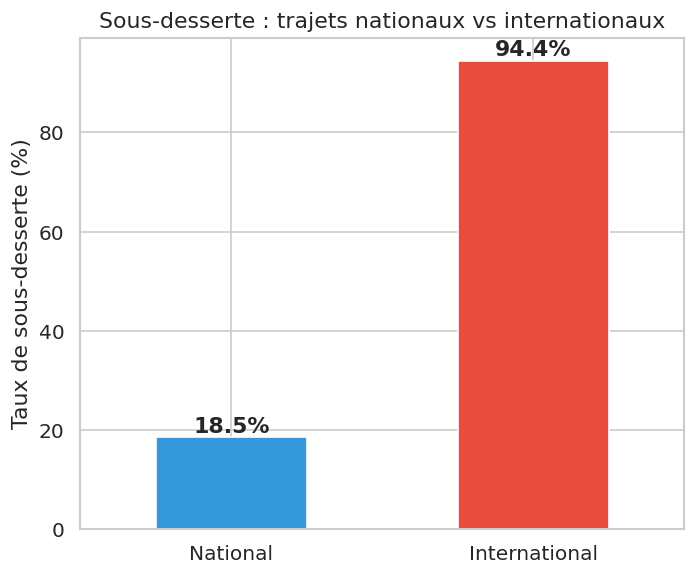

In [4]:
taux_par_international = df.groupby('is_international')['is_underserved'].agg(['count', 'mean'])
taux_par_international.columns = ['nb_routes', 'taux_sous_desserte']
taux_par_international['taux_pct'] = (taux_par_international['taux_sous_desserte'] * 100).round(1)
taux_par_international.index = ['National', 'International']

print('Taux de sous-desserte selon le caractère international :')
display(taux_par_international)

# Test du Chi²
contingency_intl = pd.crosstab(df['is_international'], df['is_underserved'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_intl)
print(f'\nTest du Chi² (is_underserved ~ is_international) :')
print(f'  chi2 = {chi2:.2f}, p-value = {p_value:.2e}')

ecart = taux_par_international.loc['International', 'taux_pct'] - taux_par_international.loc['National', 'taux_pct']
print(f'\nÉcart International - National : {ecart:+.1f} points')
if ecart > 0 and p_value < 0.05:
    print('-> Cohérent avec l\'hypothèse métier : les trajets internationaux sont significativement plus sous-desservis.')
elif p_value >= 0.05:
    print('-> Pas de différence significative entre national et international.')
else:
    print('-> Résultat contraire à l\'hypothèse métier initiale, à investiguer.')

fig, ax = plt.subplots(figsize=(6, 5))
taux_par_international['taux_pct'].plot(kind='bar', color=['#3498db', '#e74c3c'], ax=ax)
ax.set_ylabel('Taux de sous-desserte (%)')
ax.set_title('Sous-desserte : trajets nationaux vs internationaux')
ax.set_xticklabels(['National', 'International'], rotation=0)
for i, v in enumerate(taux_par_international['taux_pct']):
    ax.text(i, v + 1, f'{v}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'coherence_international.png')
plt.show()

## 4. Cohérence selon la distance du trajet

On compare la distribution de `log_distance` entre les routes sous-desservies et les routes bien desservies.

>  **Test mécaniquement garanti — contrôle de cohérence interne, pas preuve indépendante.**
> La cible est définie par `distance_km > 100` (entre autres). `log_distance` étant une transformation monotone de `distance_km`, la différence ci-dessous **ne peut pas** sortir autrement : elle est imposée par la construction de la cible. C'est exactement l'enjeu « labellisation incorrecte » documenté ailleurs dans le projet (et qui explique la domination de `log_distance` en SHAP). On garde ce test comme **vérification de cohérence interne**, en étant explicite qu'il ne constitue **pas** une validation indépendante.

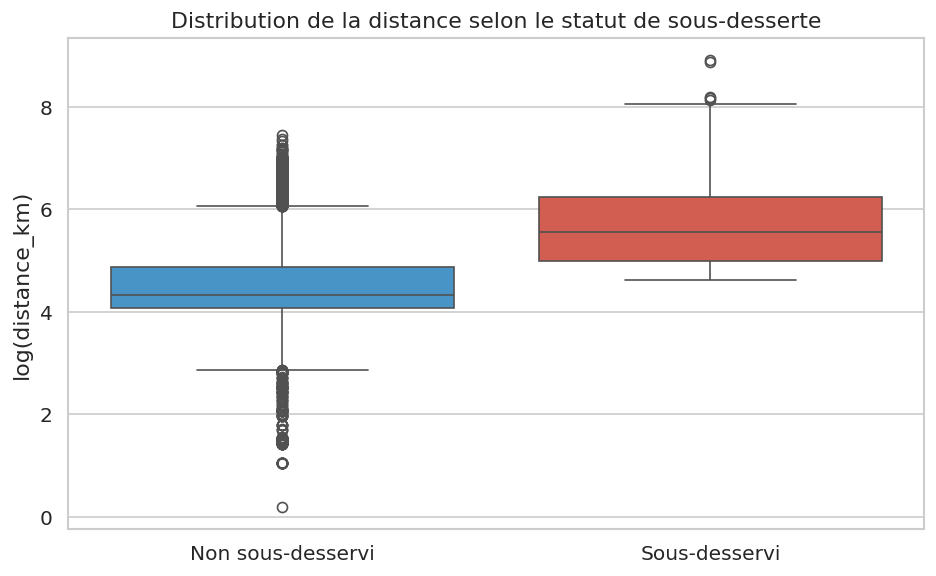

Médiane log_distance — sous-desservi     : 5.56
Médiane log_distance — non sous-desservi : 4.33

Test de Mann-Whitney : U = 85428748, p-value = 0.00e+00
-> Différence significative (attendue : distance_km entre dans la définition de la cible).


In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='is_underserved', y='log_distance', ax=ax,
            palette=['#3498db', '#e74c3c'])
ax.set_xticklabels(['Non sous-desservi', 'Sous-desservi'])
ax.set_xlabel('')
ax.set_ylabel('log(distance_km)')
ax.set_title('Distribution de la distance selon le statut de sous-desserte')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'coherence_distance.png')
plt.show()

# Test de Mann-Whitney (non-paramétrique, adapté à des distributions potentiellement non-normales)
dist_underserved = df[df['is_underserved'] == 1]['log_distance']
dist_served      = df[df['is_underserved'] == 0]['log_distance']

u_stat, p_value = stats.mannwhitneyu(dist_underserved, dist_served, alternative='two-sided')
print(f'Médiane log_distance — sous-desservi     : {dist_underserved.median():.2f}')
print(f'Médiane log_distance — non sous-desservi : {dist_served.median():.2f}')
print(f'\nTest de Mann-Whitney : U = {u_stat:.0f}, p-value = {p_value:.2e}')
if p_value < 0.05:
    print('-> Différence significative (attendue : distance_km entre dans la définition de la cible).')
else:
    print('-> Pas de différence significative de distance entre les deux groupes.')

## 5. Cohérence selon la part modale ferroviaire du pays

Hypothèse métier : un pays où le train occupe une faible part modale (peu utilisé dans la mobilité globale) devrait logiquement présenter davantage de lignes sous-desservies, par manque d'investissement historique dans le réseau.

>  **Pseudo-réplication** : `rail_modal_share` est **constant par pays** — toutes les routes d'un même pays partagent la même valeur. Tester sur les 25 200 routes traite des observations corrélées comme indépendantes et **gonfle massivement** la significativité (d'où le p ≈ 1e-37 alors que les médianes des deux groupes sont identiques). Le bon niveau d'agrégation est **le pays** (≈ 24-34 pays, pas 25 200 routes). On effectue donc d'abord le test brut (pour mémoire / reproduire l'ancien résultat), puis un test correct au niveau pays.

In [6]:
# Coup d'œil rapide : moyenne de la part modale par groupe (relocalisé ici depuis la section 4)
print('Moyenne rail_modal_share par groupe :')
display(df.groupby('is_underserved')['rail_modal_share'].mean())

Moyenne rail_modal_share par groupe :


is_underserved
0    8.698848
1    9.246061
Name: rail_modal_share, dtype: float64

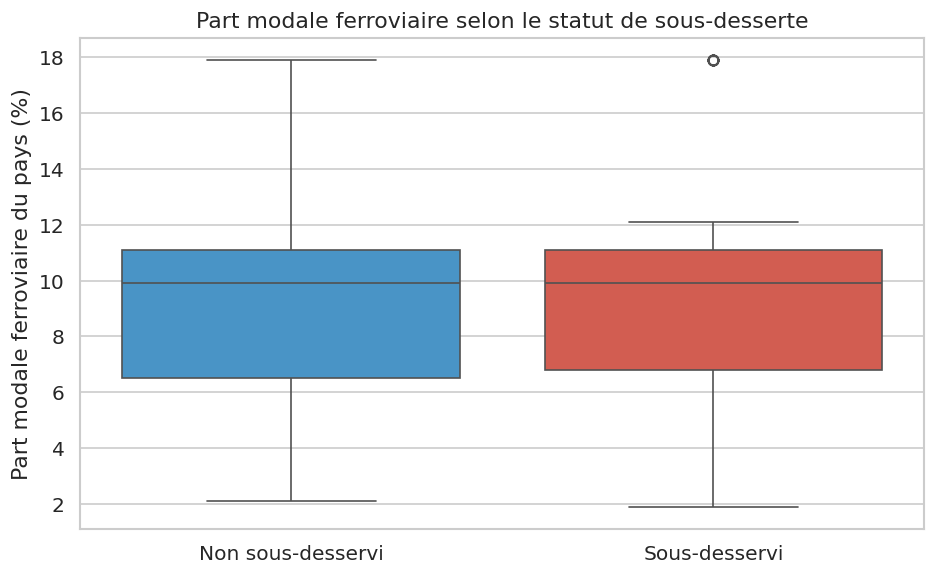

[Niveau route — BIAISÉ par pseudo-réplication]
Médiane rail_modal_share — sous-desservi     : 9.90
Médiane rail_modal_share — non sous-desservi : 9.90
Test de Mann-Whitney : U = 55374852, p-value = 1.54e-37
  -> p artificiellement minuscule : médianes identiques, significativité portée par n=25200.

[Niveau pays — n = 24 pays] Corrélation de Spearman
  part modale vs taux de sous-desserte : rho = 0.438, p-value = 0.032
  -> Relation significative même au bon niveau d'agrégation.


In [7]:
# --- (a) Test brut au niveau route (BIAISÉ par pseudo-réplication, conservé pour transparence) ---
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='is_underserved', y='rail_modal_share', ax=ax,
            palette=['#3498db', '#e74c3c'])
ax.set_xticklabels(['Non sous-desservi', 'Sous-desservi'])
ax.set_xlabel('')
ax.set_ylabel('Part modale ferroviaire du pays (%)')
ax.set_title('Part modale ferroviaire selon le statut de sous-desserte')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'coherence_modal_share.png')
plt.show()

modal_underserved = df[df['is_underserved'] == 1]['rail_modal_share']
modal_served      = df[df['is_underserved'] == 0]['rail_modal_share']

u_stat, p_value = stats.mannwhitneyu(modal_underserved, modal_served, alternative='two-sided')
print('[Niveau route — BIAISÉ par pseudo-réplication]')
print(f'Médiane rail_modal_share — sous-desservi     : {modal_underserved.median():.2f}')
print(f'Médiane rail_modal_share — non sous-desservi : {modal_served.median():.2f}')
print(f'Test de Mann-Whitney : U = {u_stat:.0f}, p-value = {p_value:.2e}')
print('  -> p artificiellement minuscule : médianes identiques, significativité portée par n=25200.')

# --- (b) Test correct au niveau PAYS (une observation par pays) ---
pays_modal = (
    df.groupby('departure_country')
      .agg(taux_sous_desserte=('is_underserved', 'mean'),
           rail_modal_share=('rail_modal_share', 'first'),
           nb_routes=('is_underserved', 'count'))
      .reset_index()
)
pays_modal_fiables = pays_modal[pays_modal['nb_routes'] >= 30]

rho, p_rho = stats.spearmanr(pays_modal_fiables['rail_modal_share'],
                             pays_modal_fiables['taux_sous_desserte'])
print(f'\n[Niveau pays — n = {len(pays_modal_fiables)} pays] Corrélation de Spearman')
print(f'  part modale vs taux de sous-desserte : rho = {rho:.3f}, p-value = {p_rho:.3f}')
if p_rho < 0.05:
    print('  -> Relation significative même au bon niveau d\'agrégation.')
else:
    print('  -> Relation NON significative une fois la pseudo-réplication corrigée :')
    print('     l\'effet « part modale » est en réalité ténu / non concluant.')

## 6. Cohérence selon le type de service (jour / nuit)

Déjà observé dans `data_prep.py` (75,4% de sous-desserte pour les trains de nuit contre 17,9% pour les trains de jour), repris ici comme test de cohérence formel.

>  **Deux réserves.** (1) **Circularité partielle** : les trains de nuit roulent en moyenne moins de jours par an, et `days_active` entre dans la définition de la cible — une partie de l'écart est donc imposée par la construction de la cible. (2) **Fiabilité de `service_type`** : le bucket « nuit » du flux EU contient vraisemblablement des trains de jour mal étiquetés (ICE dans des flux de nuit), donc le 75,4 % repose en partie sur un libellé imparfait. À présenter comme cohérent mais à ne pas survendre.

In [8]:
taux_par_type = df.groupby('service_type')['is_underserved'].agg(['count', 'mean'])
taux_par_type.columns = ['nb_routes', 'taux_sous_desserte']
taux_par_type['taux_pct'] = (taux_par_type['taux_sous_desserte'] * 100).round(1)

print('Taux de sous-desserte selon le type de service :')
display(taux_par_type)

contingency_type = pd.crosstab(df['service_type'], df['is_underserved'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_type)
print(f'\nTest du Chi² (is_underserved ~ service_type) :')
print(f'  chi2 = {chi2:.2f}, p-value = {p_value:.2e}')
if p_value < 0.05:
    print('-> Différence significative entre trains de jour et de nuit')
    print('   (cohérent avec le secteur ; réserves : circularité days_active + fiabilité du libellé nuit).')

Taux de sous-desserte selon le type de service :


,nb_routes,taux_sous_desserte,taux_pct
service_type,,,
day,24542,0.178918,17.9
night,658,0.753799,75.4



Test du Chi² (is_underserved ~ service_type) :
  chi2 = 1351.13, p-value = 8.75e-296
-> Différence significative entre trains de jour et de nuit
   (cohérent avec le secteur ; réserves : circularité days_active + fiabilité du libellé nuit).


## 7. Synthèse de la cohérence de `is_underserved`

**Pourquoi pas de cartographie de gares**

Le dataset ne contient que le pays de départ et d'arrivée (`departure_country`, `arrival_country`), sans coordonnées GPS de gares individuelles. Une cartographie de gares au sens strict n'est donc pas réalisable sans intégrer une source externe (coordonnées GTFS `stops.txt` ou `cities15000.txt`), ce qui sort du périmètre de données validé pour ce projet. Pour répondre à l'intention du professeur — vérifier que `is_underserved` est **structurée** plutôt qu'aléatoire — cinq tests de cohérence ont été menés sur les 25 200 routes (taux global : 19,4 %).

>  **Cadre d'interprétation.** Ces tests montrent que `is_underserved` est **structurée par des facteurs géographiques et opérationnels, et non distribuée aléatoirement**. Ils ne constituent **pas** une validation contre une vérité terrain indépendante : plusieurs tests portent sur des variables qui servent à *construire* la cible (distance, indirectement international et type de service), et sont donc des contrôles de **cohérence interne** plutôt que des preuves externes. Les signaux les plus proches d'une structure indépendante sont le **pays** et la **part modale**.

1. **Pays — structure confirmée (signal le plus proche de l'indépendance).**
La sous-desserte dépend très significativement du pays de départ (Chi², χ² ≈ 1214, p ≈ 5e-234). Parmi les pays à volume suffisant (≥ 30 routes), les taux s'étendent de ~1,7 % (Slovénie) à ~93 % (Ukraine), écart-type ~23 points. Cette hétérogénéité confirme que la cible capte une structuration réelle du réseau. *(Réserve technique : avec les petits pays, certaines cellules attendues du Chi² passent sous 5 ; on s'appuie sur le sens du résultat, pas sur χ² exact.)*

2. **International — cohérent mais partiellement circulaire.**
Les trajets internationaux affichent ~94 % de sous-desserte contre ~18,5 % en national (Chi², p ≈ 3e-229). C'est l'écart le plus marqué, **mais** les trajets internationaux sont aussi nettement plus longs : une partie de l'effet est un effet de distance déguisé, donc imposé par la définition de la cible. Signal cohérent, ampleur amplifiée par la construction.

3. **Distance — mécaniquement garanti (cohérence interne, pas preuve).**
`log_distance` diffère fortement entre les deux groupes (Mann-Whitney, p sous le seuil de précision numérique). Ce résultat **ne peut pas** sortir autrement : `distance_km > 100` *définit* en partie la cible. C'est l'enjeu « labellisation incorrecte » connu du projet. À présenter comme contrôle de cohérence interne, jamais comme validation.

4. **Part modale — effet ténu une fois la pseudo-réplication corrigée.**
Au niveau route, le test ressort « significatif » (p ≈ 1e-37) **alors que les médianes des deux groupes sont identiques (9,90)** : c'est un artefact de pseudo-réplication, `rail_modal_share` étant constant par pays. Testée au bon niveau (corrélation de Spearman sur ~24-34 **pays**, pas 25 200 routes), la relation est bien plus modeste — et largement redondante avec l'effet « pays » de la section 1. À documenter comme une nuance, pas comme un cinquième signal indépendant. *(Voir la sortie de la section 5 pour le rho et le p au niveau pays.)*

5. **Type de service — cohérent, avec deux réserves.**
Trains de nuit ~75,4 % vs jour ~17,9 % (Chi², p ≈ 9e-296). Réserves : (a) les trains de nuit roulent moins de jours/an et `days_active` entre dans la cible (circularité partielle) ; (b) le libellé « nuit » contient probablement des trains de jour mal classés (ICE dans des flux de nuit), donc `service_type` est partiellement peu fiable.

**Conclusion**

Pris ensemble, ces tests établissent que `is_underserved` est **structurée par la géographie et l'exploitation ferroviaire, et non aléatoire** — ce qui répond à l'intention du professeur. Ils ne constituent toutefois **pas une validation contre une vérité terrain indépendante** : les tests de distance et de type de service reflètent en partie la **construction même de la cible** (cohérence interne), et le test de part modale est largement redondant avec l'effet pays une fois la pseudo-réplication corrigée. Les éléments les plus proches d'une structure indépendante sont l'**effet pays** et, plus modestement, la **part modale au niveau pays**. Enfin, ces tests portent sur l'intégralité de `routes_processed.csv`, qui inclut des pays **exclus de la modélisation** (CH, TR, UA, etc.) : à garder en tête pour l'interprétation. En l'absence de données de fréquentation réelles ou de coordonnées de gares, c'est le niveau de preuve atteignable — solide pour « non aléatoire », insuffisant pour « validé ».